In [ ]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf

# 📊 Guía Rápida: Finanzas e Inversiones

**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**  
Facultad de Ciencias Económicas - Universidad de Buenos Aires

---

## 📚 Contenidos

### 🔹 Fundamentos
1. [Conversión de Tasas](#conversiones)
2. [Valor Temporal del Dinero](#valor-temporal)

### 🔹 Métricas de Evaluación
3. [VAN - Valor Actual Neto](#van)
4. [TIR - Tasa Interna de Retorno](#tir)
5. [Otras Métricas (TIRM, IR, PRS, PRD)](#otras-metricas)

### 🔹 Aplicación
6. [Workflow de Análisis](#workflow)
7. [Caso Práctico Completo](#caso-practico)
8. [Tabla de Fórmulas](#formulas)

---

---

<a id="conversiones"></a>

## 1️⃣ Conversión de Tasas

### 📌 Nomenclatura Estándar

| Sigla | Significado | Característica |
|-------|-------------|----------------|
| **TNA** | Tasa Nominal Anual | Proporción simple (sin capitalización) |
| **TEA** | Tasa Efectiva Anual | Con capitalización incluida |
| **TEM** | Tasa Efectiva Mensual | Efectiva mensual |
| **TET** | Tasa Efectiva Trimestral | Efectiva trimestral |
| **TES** | Tasa Efectiva Semestral | Efectiva semestral |

### 📐 Fórmulas de Conversión

#### **1. De TNA a Tasa Efectiva (cualquier período)**

$$
\text{Tasa Efectiva} = \left(1 + \frac{TNA}{m}\right)^m - 1
$$

Donde $m$ = número de capitalizaciones al año

**Ejemplo:** TNA = 12% con capitalización mensual → TEA

$$
TEA = \left(1 + \frac{0.12}{12}\right)^{12} - 1 = 0.1268 = 12.68\%
$$

#### **2. Equivalencia entre Tasas Efectivas**

$$
\left(1 + i_1\right)^{t_1} = \left(1 + i_2\right)^{t_2}
$$

**Ejemplo:** De TEA a TEM

$$
(1 + TEA)^{1} = (1 + TEM)^{12}
$$

$$
TEM = (1 + TEA)^{1/12} - 1
$$

#### **3. Proporción Simple (sin capitalización)**

$$
i_{\text{período}} = TNA \times \frac{\text{días}}{\text{360 o 365}}
$$

**Ejemplo:** TNA = 24% para 30 días

$$
i_{30\text{días}} = 0.24 \times \frac{30}{360} = 0.02 = 2\%
$$


In [ ]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS PRÁCTICOS DE CONVERSIÓN DE TASAS
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("CONVERSIONES DE TASAS - EJEMPLOS PRÁCTICOS")
print("="*70)

# ───────────────────────────────────────────────────────────────
# CASO 1: Banco ofrece TNA 36% con capitalización mensual
# ───────────────────────────────────────────────────────────────

print("\n📌 CASO 1: TNA 36% con capitalización mensual → TEA")
print("-"*70)

TNA = 0.36
m = 12  # capitalizaciones mensuales

TEA = (1 + TNA/m)**m - 1

print(f"TNA:                     {TNA:.2%}")
print(f"Capitalizaciones/año:    {m}")
print(f"TEA equivalente:         {TEA:.4%}")
print(f"\n💡 Interpretación: El 36% nominal equivale a {TEA:.2%} efectivo anual")

# ───────────────────────────────────────────────────────────────
# CASO 2: TEA 15% → TEM (mensual efectiva)
# ───────────────────────────────────────────────────────────────

print("\n\n📌 CASO 2: TEA 15% → TEM")
print("-"*70)

TEA = 0.15
TEM = (1 + TEA)**(1/12) - 1

print(f"TEA:                     {TEA:.2%}")
print(f"TEM equivalente:         {TEM:.4%}")
print(f"\n💡 Verificación: (1 + {TEM:.4%})^12 - 1 = {((1 + TEM)**12 - 1):.4%}")

# ───────────────────────────────────────────────────────────────
# CASO 3: TNA 24% → Tasa para 45 días (proporción simple)
# ───────────────────────────────────────────────────────────────

print("\n\n📌 CASO 3: TNA 24% → Tasa para 45 días (proporción)")
print("-"*70)

TNA = 0.24
dias = 45

tasa_45dias = TNA * (dias/360)  # base 360 días (convención bancaria)

print(f"TNA:                     {TNA:.2%}")
print(f"Período:                 {dias} días")
print(f"Tasa 45 días:            {tasa_45dias:.4%}")
print(f"\n💡 Interpretación: Sin capitalización, proporción simple")

# ───────────────────────────────────────────────────────────────
# CASO 4: TET 8% → TEA (trimestral a anual)
# ───────────────────────────────────────────────────────────────

print("\n\n📌 CASO 4: TET 8% → TEA")
print("-"*70)

TET = 0.08
TEA_desde_trim = (1 + TET)**4 - 1  # 4 trimestres al año

print(f"TET:                     {TET:.2%}")
print(f"TEA equivalente:         {TEA_desde_trim:.4%}")
print(f"\n💡 Interpretación: 8% trimestral equivale a {TEA_desde_trim:.2%} anual")

# ───────────────────────────────────────────────────────────────
# TABLA RESUMEN
# ───────────────────────────────────────────────────────────────

print("\n\n" + "="*70)
print("TABLA RESUMEN DE CONVERSIONES")
print("="*70)

conversiones = pd.DataFrame({
    'Caso': ['TNA 36% (cap. mensual)', 'TEA 15%', 'TNA 24% (45 días)', 'TET 8%'],
    'Tasa Origen': ['TNA 36.00%', 'TEA 15.00%', 'TNA 24.00%', 'TET 8.00%'],
    'Tasa Destino': ['TEA 42.58%', 'TEM 1.17%', 'i_45d 3.00%', 'TEA 36.05%'],
    'Método': ['Capitalización', 'Equivalencia', 'Proporción', 'Capitalización']
})

print(conversiones.to_string(index=False))

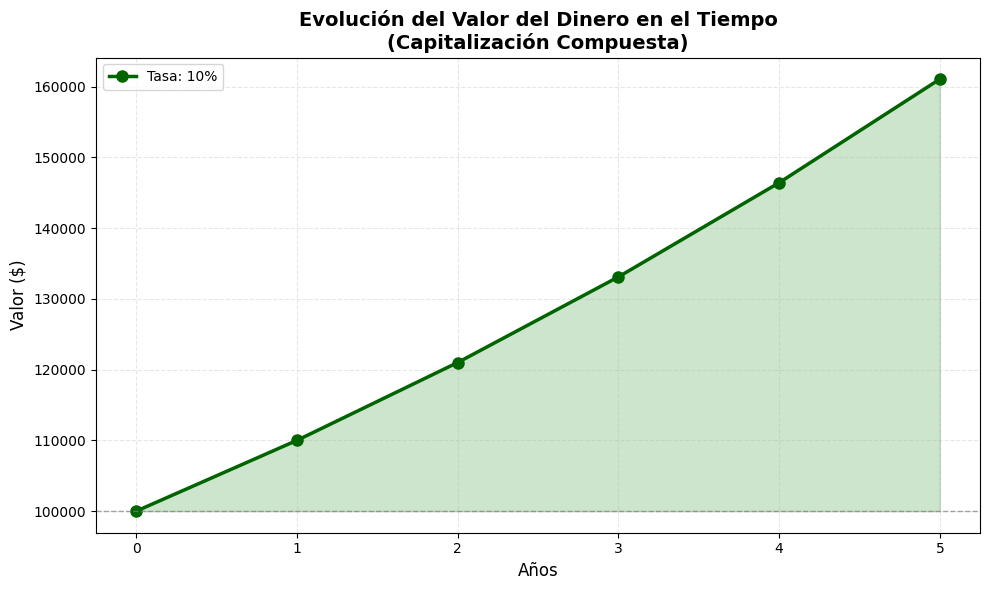


📊 Interpretación de los gráficos:
   • CAPITALIZACIÓN (izq): El dinero crece con el tiempo
   • DESCUENTO (der): El valor presente disminuye cuanto más lejano sea el futuro
   • Ambos procesos son exponenciales (no lineales)


In [3]:
# Visualización: Crecimiento del Valor en el Tiempo

años_rango = np.arange(0, años + 1)
valores_futuros = vp_inicial * (1 + tasa_anual) ** años_rango

plt.figure(figsize=(10, 6))
plt.plot(años_rango, valores_futuros, marker='o', linewidth=2.5, 
         color='darkgreen', markersize=8, label=f'Tasa: {tasa_anual:.0%}')
plt.axhline(vp_inicial, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.fill_between(años_rango, vp_inicial, valores_futuros, alpha=0.2, color='green')

plt.title('Evolución del Valor del Dinero en el Tiempo\n(Capitalización Compuesta)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Años', fontsize=12)
plt.ylabel('Valor ($)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n📊 Interpretación de los gráficos:")
print("   • CAPITALIZACIÓN (izq): El dinero crece con el tiempo")
print("   • DESCUENTO (der): El valor presente disminuye cuanto más lejano sea el futuro")
print("   • Ambos procesos son exponenciales (no lineales)")

---

<a id="marco-metodologico"></a>

## 4️⃣ Los 5 Pilares del Análisis Financiero

A diferencia de las integrales (donde existe un proceso matemático paso a paso), el análisis financiero de inversiones se basa en un **marco conceptual estructurado** que guía la toma de decisiones.

### 🏛️ Los 5 Pilares Fundamentales

```
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  1. CONTEXTO  →  2. FLUJOS  →  3. TASA  →  4. MÉTRICAS  →  5. DECISIÓN │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

#### **Pilar 1: Contexto del Proyecto** 🎯

**¿Qué estamos evaluando?**

- **Tipo de proyecto**: Inversión productiva, financiera, inmobiliaria
- **Horizonte temporal**: Corto, mediano o largo plazo
- **Objetivo**: Rentabilidad, recuperación rápida, minimizar riesgo
- **Restricciones**: Capital disponible, financiamiento, regulaciones

**Preguntas clave:**
- ¿Cuál es el propósito de la inversión?
- ¿Cuánto tiempo durará el proyecto?
- ¿Hay alternativas de inversión?

#### **Pilar 2: Flujos de Caja** 💰

**¿Cuánto dinero entra y sale, y cuándo?**

- **Inversión inicial** (t=0): Desembolso inicial (negativo)
- **Flujos operativos** (t=1, 2, ...): Ingresos menos costos
- **Valor residual** (t=n): Recuperación al final del proyecto

**Estructura típica:**

```
t=0:     -$100,000  (Inversión inicial)
t=1:     +$30,000   (Flujo año 1)
t=2:     +$40,000   (Flujo año 2)
t=3:     +$50,000   (Flujo año 3)
...
```

**Preguntas clave:**
- ¿Cuál es la inversión inicial total?
- ¿Qué flujos operativos generará el proyecto?
- ¿Hay valor de salvamento o residual?

#### **Pilar 3: Tasa de Descuento** 📊

**¿A qué tasa descontamos los flujos futuros?**

La tasa de descuento ($r$ o $k$) representa el **costo de oportunidad del capital**.

**Métodos de determinación:**

1. **CAPM (Capital Asset Pricing Model)**:
   $$r = r_f + \beta (r_m - r_f)$$
   - $r_f$: Tasa libre de riesgo
   - $\beta$: Medida de riesgo sistemático
   - $r_m$: Rendimiento esperado del mercado

2. **WACC (Weighted Average Cost of Capital)**:
   $$WACC = \frac{E}{V} \cdot r_e + \frac{D}{V} \cdot r_d \cdot (1 - T_c)$$
   - Para proyectos con financiamiento mixto (deuda + capital propio)

3. **Tasa de Referencia**: Benchmarks del sector o rendimientos históricos

**Preguntas clave:**
- ¿Cuál es el costo de oportunidad?
- ¿Hay riesgo adicional a considerar?
- ¿El proyecto tiene financiamiento externo?

#### **Pilar 4: Métricas de Evaluación** 📏

**¿Cómo medimos la viabilidad del proyecto?**

Conjunto de herramientas cuantitativas:

| Métrica | Pregunta que responde | Criterio de aceptación |
|---------|----------------------|----------------------|
| **VAN** | ¿Cuánto valor agregamos? | VAN > 0 |
| **TIR** | ¿Qué rendimiento obtenemos? | TIR > r |
| **TIRM** | ¿TIR ajustada por reinversión? | TIRM > r |
| **IR** | ¿Cuánto ganamos por peso invertido? | IR > 1 |
| **PRS** | ¿Cuándo recuperamos la inversión? | PRS < límite aceptable |
| **PRD** | ¿Cuándo recuperamos (descontado)? | PRD < límite aceptable |

**Preguntas clave:**
- ¿El proyecto crea valor (VAN > 0)?
- ¿El rendimiento supera el costo de capital (TIR > r)?
- ¿Qué tan rápido recuperamos la inversión?

#### **Pilar 5: Decisión y Análisis de Sensibilidad** ✅

**¿Aceptamos o rechazamos el proyecto?**

**Regla de decisión integrada:**

```
✅ ACEPTAR si:
   • VAN > 0
   • TIR > r (tasa de descuento)
   • TIRM > r
   • IR > 1
   • PRS/PRD < límite aceptable

❌ RECHAZAR si:
   • VAN < 0
   • TIR < r
   • Recuperación demasiado lenta
```

**Análisis de sensibilidad:**
- ¿Qué pasa si los flujos son 10% menores?
- ¿Cómo afecta un aumento en la tasa de descuento?
- ¿Cuál es el escenario pesimista/optimista?

**Preguntas clave:**
- ¿Las métricas apuntan en la misma dirección?
- ¿Hay contradicciones entre métricas?
- ¿Qué tan sensible es la decisión a cambios en supuestos?

---

### 🔄 Interrelación entre los 5 Pilares

Los pilares NO son independientes, sino que se retroalimentan:

```
CONTEXTO ──► determina ──► FLUJOS
    │                        │
    │                        ▼
    └────► define ──────► TASA
                            │
                            ▼
                        MÉTRICAS
                            │
                            ▼
                        DECISIÓN
```

**Ejemplo de retroalimentación:**
- Un contexto de **alto riesgo** requiere una **tasa de descuento mayor**
- **Flujos inciertos** pueden llevar a usar **TIRM** en lugar de TIR
- **Restricciones de liquidez** priorizan **PRS** sobre VAN

---


<a id="workflow"></a>

## 5️⃣ Workflow de Análisis: Del Contexto a la Decisión

### 📋 Proceso Sistemático de Evaluación

A continuación se presenta el **workflow completo** para evaluar un proyecto de inversión:

```
┌──────────────────────────────────────────────────────────────┐
│                     WORKFLOW DE ANÁLISIS                     │
└──────────────────────────────────────────────────────────────┘

ETAPA 1: RECOPILACIÓN DE INFORMACIÓN
├─ ✅ Definir objetivo del proyecto
├─ ✅ Identificar inversión inicial
├─ ✅ Proyectar flujos de caja operativos
├─ ✅ Estimar valor residual (si aplica)
└─ ✅ Definir horizonte temporal

ETAPA 2: DETERMINACIÓN DE LA TASA DE DESCUENTO
├─ ✅ Identificar tasa libre de riesgo
├─ ✅ Evaluar riesgo del proyecto (β)
├─ ✅ Calcular tasa de descuento (CAPM o WACC)
└─ ✅ Ajustar por frecuencia (anual → mensual si aplica)

ETAPA 3: PREPARACIÓN DE DATOS
├─ ✅ Estructurar flujos en DataFrame/Lista
├─ ✅ Verificar signos (inversión negativa, flujos positivos)
├─ ✅ Confirmar unidades temporales consistentes
└─ ✅ Validar completitud de datos

ETAPA 4: CÁLCULO DE MÉTRICAS
├─ ✅ Calcular VAN (numpy_financial.npv)
├─ ✅ Calcular TIR (numpy_financial.irr)
├─ ✅ Calcular TIRM (numpy_financial.mirr)
├─ ✅ Calcular IR (VAN / Inversión Inicial)
├─ ✅ Calcular PRS (recuperación simple)
└─ ✅ Calcular PRD (recuperación descontada)

ETAPA 5: INTERPRETACIÓN Y DECISIÓN
├─ ✅ Comparar VAN con 0
├─ ✅ Comparar TIR/TIRM con tasa de descuento
├─ ✅ Evaluar IR (> 1 o < 1)
├─ ✅ Verificar consistencia entre métricas
└─ ✅ Tomar decisión (Aceptar/Rechazar/Revisar)

ETAPA 6: ANÁLISIS DE SENSIBILIDAD (Opcional pero recomendado)
├─ ✅ Escenario pesimista (flujos -20%)
├─ ✅ Escenario optimista (flujos +20%)
├─ ✅ Variación en tasa de descuento (±2%)
└─ ✅ Análisis de punto de equilibrio

ETAPA 7: VISUALIZACIÓN Y REPORTE
├─ ✅ Gráfico de flujos de caja
├─ ✅ Gráfico de recuperación (PRS/PRD)
├─ ✅ Tabla resumen de métricas
└─ ✅ Recomendación fundamentada
```

---

### 🛠️ Template de Código Reutilizable

A continuación, un **template genérico** que podés adaptar a cualquier proyecto:


In [4]:
# ═══════════════════════════════════════════════════════════════
# TEMPLATE GENÉRICO PARA EVALUACIÓN DE PROYECTOS DE INVERSIÓN
# ═══════════════════════════════════════════════════════════════

def evaluar_proyecto(flujos, tasa_descuento_anual, nombre_proyecto="Proyecto"):
    """
    Evalúa un proyecto de inversión calculando todas las métricas relevantes.
    
    Args:
        flujos (list): Lista de flujos de caja [F0, F1, F2, ..., Fn]
                      F0 debe ser negativo (inversión inicial)
        tasa_descuento_anual (float): Tasa de descuento anual (decimal, ej: 0.10)
        nombre_proyecto (str): Nombre descriptivo del proyecto
    
    Returns:
        dict: Diccionario con todas las métricas calculadas
    """
    
    print("="*80)
    print(f"EVALUACIÓN DE INVERSIÓN: {nombre_proyecto.upper()}")
    print("="*80)
    
    # ────────────────────────────────────────────────────────────
    # ETAPA 1: INFORMACIÓN BÁSICA
    # ────────────────────────────────────────────────────────────
    
    inversion_inicial = abs(flujos[0])
    n_periodos = len(flujos) - 1
    
    print(f"\n📌 INFORMACIÓN BÁSICA:")
    print(f"   • Inversión inicial:         ${inversion_inicial:,.2f}")
    print(f"   • Horizonte temporal:        {n_periodos} períodos")
    print(f"   • Tasa de descuento anual:   {tasa_descuento_anual:.2%}")
    print(f"   • Flujos de caja:            {len(flujos)} valores")
    
    # ────────────────────────────────────────────────────────────
    # ETAPA 2: CÁLCULO DE MÉTRICAS
    # ────────────────────────────────────────────────────────────
    
    print(f"\n" + "="*80)
    print("CÁLCULO DE MÉTRICAS FINANCIERAS")
    print("="*80)
    
    # 1. VAN (Valor Actual Neto)
    van = npf.npv(tasa_descuento_anual, flujos)
    
    print(f"\n1️⃣ VALOR ACTUAL NETO (VAN)")
    print(f"   VAN = ${van:,.2f}")
    if van > 0:
        print(f"   ✅ VAN > 0 → El proyecto CREA valor")
    elif van < 0:
        print(f"   ❌ VAN < 0 → El proyecto DESTRUYE valor")
    else:
        print(f"   ⚠️ VAN = 0 → El proyecto es INDIFERENTE")
    
    # 2. TIR (Tasa Interna de Retorno)
    try:
        tir = npf.irr(flujos)
        print(f"\n2️⃣ TASA INTERNA DE RETORNO (TIR)")
        print(f"   TIR = {tir:.4%}")
        if tir > tasa_descuento_anual:
            print(f"   ✅ TIR ({tir:.2%}) > r ({tasa_descuento_anual:.2%}) → Proyecto RENTABLE")
        else:
            print(f"   ❌ TIR ({tir:.2%}) < r ({tasa_descuento_anual:.2%}) → Proyecto NO rentable")
    except:
        tir = None
        print(f"\n2️⃣ TASA INTERNA DE RETORNO (TIR)")
        print(f"   ⚠️ No se pudo calcular TIR (flujos no convencionales)")
    
    # 3. TIRM (TIR Modificada)
    try:
        tirm = npf.mirr(flujos, tasa_descuento_anual, tasa_descuento_anual)
        print(f"\n3️⃣ TASA INTERNA DE RETORNO MODIFICADA (TIRM)")
        print(f"   TIRM = {tirm:.4%}")
        if tirm > tasa_descuento_anual:
            print(f"   ✅ TIRM ({tirm:.2%}) > r ({tasa_descuento_anual:.2%}) → Proyecto RENTABLE")
        else:
            print(f"   ❌ TIRM ({tirm:.2%}) < r ({tasa_descuento_anual:.2%}) → Proyecto NO rentable")
    except:
        tirm = None
        print(f"\n3️⃣ TASA INTERNA DE RETORNO MODIFICADA (TIRM)")
        print(f"   ⚠️ No se pudo calcular TIRM")
    
    # 4. IR (Índice de Rentabilidad)
    ir = van / inversion_inicial
    print(f"\n4️⃣ ÍNDICE DE RENTABILIDAD (IR)")
    print(f"   IR = VAN / Inversión Inicial")
    print(f"   IR = ${van:,.2f} / ${inversion_inicial:,.2f}")
    print(f"   IR = {ir:.4f}")
    if ir > 0:
        print(f"   ✅ IR > 0 → Por cada $1 invertido, se generan ${ir:.2f} de VAN")
    else:
        print(f"   ❌ IR < 0 → El proyecto genera pérdidas")
    
    # 5. PRS (Período de Recuperación Simple)
    flujo_acumulado = 0
    prs = None
    for t in range(len(flujos)):
        flujo_acumulado += flujos[t]
        if flujo_acumulado >= 0 and prs is None:
            if t > 0:
                flujo_previo = sum(flujos[:t])
                prs = t - 1 + abs(flujo_previo) / flujos[t]
            else:
                prs = 0
            break
    
    print(f"\n5️⃣ PERÍODO DE RECUPERACIÓN SIMPLE (PRS)")
    if prs is not None:
        print(f"   PRS = {prs:.2f} períodos")
        print(f"   ✅ La inversión se recupera en {prs:.2f} períodos (sin descontar)")
    else:
        print(f"   ⚠️ La inversión NO se recupera en el horizonte del proyecto")
    
    # 6. PRD (Período de Recuperación Descontado)
    flujo_desc_acum = 0
    prd = None
    for t in range(len(flujos)):
        if t == 0:
            flujo_desc = flujos[t]
        else:
            flujo_desc = flujos[t] / (1 + tasa_descuento_anual) ** t
        flujo_desc_acum += flujo_desc
        
        if flujo_desc_acum >= 0 and prd is None:
            if t > 0:
                flujo_desc_previo = flujo_desc_acum - flujo_desc
                prd = t - 1 + abs(flujo_desc_previo) / abs(flujo_desc)
            else:
                prd = 0
            break
    
    print(f"\n6️⃣ PERÍODO DE RECUPERACIÓN DESCONTADO (PRD)")
    if prd is not None:
        print(f"   PRD = {prd:.2f} períodos")
        print(f"   ✅ La inversión se recupera en {prd:.2f} períodos (descontando)")
    else:
        print(f"   ⚠️ La inversión NO se recupera (descontada) en el horizonte")
    
    # ────────────────────────────────────────────────────────────
    # ETAPA 3: DECISIÓN INTEGRADA
    # ────────────────────────────────────────────────────────────
    
    print(f"\n" + "="*80)
    print("DECISIÓN FINAL")
    print("="*80)
    
    criterios_positivos = 0
    total_criterios = 0
    
    # Evaluar VAN
    if van > 0:
        print(f"\n✅ VAN > 0:    FAVORABLE")
        criterios_positivos += 1
    else:
        print(f"\n❌ VAN < 0:    DESFAVORABLE")
    total_criterios += 1
    
    # Evaluar TIR
    if tir is not None:
        if tir > tasa_descuento_anual:
            print(f"✅ TIR > r:    FAVORABLE")
            criterios_positivos += 1
        else:
            print(f"❌ TIR < r:    DESFAVORABLE")
        total_criterios += 1
    
    # Evaluar TIRM
    if tirm is not None:
        if tirm > tasa_descuento_anual:
            print(f"✅ TIRM > r:   FAVORABLE")
            criterios_positivos += 1
        else:
            print(f"❌ TIRM < r:   DESFAVORABLE")
        total_criterios += 1
    
    # Evaluar IR
    if ir > 0:
        print(f"✅ IR > 0:     FAVORABLE")
        criterios_positivos += 1
    else:
        print(f"❌ IR < 0:     DESFAVORABLE")
    total_criterios += 1
    
    # Decisión final
    porcentaje_favorable = (criterios_positivos / total_criterios) * 100
    
    print(f"\n" + "─"*80)
    print(f"RESULTADO: {criterios_positivos}/{total_criterios} criterios favorables ({porcentaje_favorable:.0f}%)")
    print("─"*80)
    
    if criterios_positivos == total_criterios:
        print(f"\n🟢 RECOMENDACIÓN: ACEPTAR el proyecto")
        print(f"   Todos los indicadores son favorables.")
    elif criterios_positivos >= total_criterios * 0.6:
        print(f"\n🟡 RECOMENDACIÓN: REVISAR el proyecto")
        print(f"   La mayoría de indicadores son favorables, pero hay dudas.")
        print(f"   Considerar análisis de sensibilidad adicional.")
    else:
        print(f"\n🔴 RECOMENDACIÓN: RECHAZAR el proyecto")
        print(f"   La mayoría de indicadores son desfavorables.")
    
    print("="*80 + "\n")
    
    # Retornar diccionario con resultados
    return {
        'VAN': van,
        'TIR': tir,
        'TIRM': tirm,
        'IR': ir,
        'PRS': prs,
        'PRD': prd,
        'criterios_positivos': criterios_positivos,
        'total_criterios': total_criterios,
        'porcentaje_favorable': porcentaje_favorable
    }

print("✅ Template de evaluación definido correctamente")
print("   Uso: resultados = evaluar_proyecto(flujos, tasa, 'Nombre Proyecto')")

✅ Template de evaluación definido correctamente
   Uso: resultados = evaluar_proyecto(flujos, tasa, 'Nombre Proyecto')


### 🧪 Ejemplo de Uso del Template

Ahora usaremos el template con un proyecto hipotético:

**Contexto:**
- Inversión inicial: $150,000
- Flujos anuales: $40,000, $50,000, $60,000, $70,000
- Tasa de descuento: 12% anual


In [5]:
# EJEMPLO DE USO DEL TEMPLATE

# Definir flujos del proyecto
flujos_ejemplo = [-150000, 40000, 50000, 60000, 70000]

# Tasa de descuento
tasa_ejemplo = 0.12  # 12% anual

# Evaluar proyecto usando el template
resultados = evaluar_proyecto(
    flujos=flujos_ejemplo,
    tasa_descuento_anual=tasa_ejemplo,
    nombre_proyecto="Expansión Planta Industrial"
)

# Los resultados quedan almacenados en el diccionario 'resultados'
print("\n📊 Resumen de métricas almacenadas:")
for metrica, valor in resultados.items():
    if valor is not None and isinstance(valor, (int, float)):
        if metrica in ['VAN']:
            print(f"   {metrica}: ${valor:,.2f}")
        elif metrica in ['TIR', 'TIRM']:
            print(f"   {metrica}: {valor:.2%}")
        elif metrica in ['IR', 'PRS', 'PRD']:
            print(f"   {metrica}: {valor:.2f}")
        else:
            print(f"   {metrica}: {valor}")

EVALUACIÓN DE INVERSIÓN: EXPANSIÓN PLANTA INDUSTRIAL

📌 INFORMACIÓN BÁSICA:
   • Inversión inicial:         $150,000.00
   • Horizonte temporal:        4 períodos
   • Tasa de descuento anual:   12.00%
   • Flujos de caja:            5 valores

CÁLCULO DE MÉTRICAS FINANCIERAS

1️⃣ VALOR ACTUAL NETO (VAN)
   VAN = $12,767.06
   ✅ VAN > 0 → El proyecto CREA valor

2️⃣ TASA INTERNA DE RETORNO (TIR)
   TIR = 15.6169%
   ✅ TIR (15.62%) > r (12.00%) → Proyecto RENTABLE

3️⃣ TASA INTERNA DE RETORNO MODIFICADA (TIRM)
   TIRM = 14.3107%
   ✅ TIRM (14.31%) > r (12.00%) → Proyecto RENTABLE

4️⃣ ÍNDICE DE RENTABILIDAD (IR)
   IR = VAN / Inversión Inicial
   IR = $12,767.06 / $150,000.00
   IR = 0.0851
   ✅ IR > 0 → Por cada $1 invertido, se generan $0.09 de VAN

5️⃣ PERÍODO DE RECUPERACIÓN SIMPLE (PRS)
   PRS = 3.00 períodos
   ✅ La inversión se recupera en 3.00 períodos (sin descontar)

6️⃣ PERÍODO DE RECUPERACIÓN DESCONTADO (PRD)
   PRD = 3.71 períodos
   ✅ La inversión se recupera en 3.71 perío

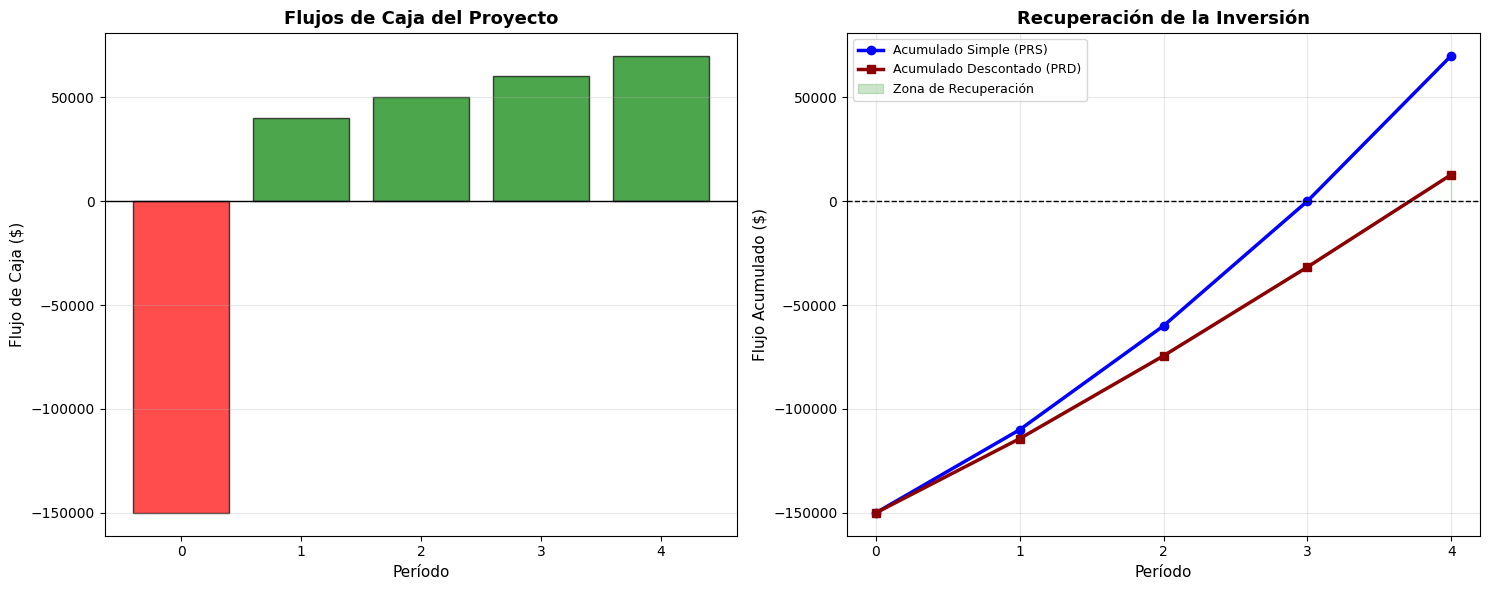


📊 Los gráficos muestran:
   • Izquierda: Distribución temporal de flujos (negativos en rojo, positivos en verde)
   • Derecha: Cómo se recupera la inversión (simple vs descontada)


In [6]:
# Visualización de Flujos y Recuperación

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Flujos de Caja
periodos = np.arange(len(flujos_ejemplo))
colores = ['red' if f < 0 else 'green' for f in flujos_ejemplo]

ax1.bar(periodos, flujos_ejemplo, color=colores, alpha=0.7, edgecolor='black')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Flujos de Caja del Proyecto', fontsize=13, fontweight='bold')
ax1.set_xlabel('Período', fontsize=11)
ax1.set_ylabel('Flujo de Caja ($)', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(periodos)

# Gráfico 2: Recuperación Acumulada
flujo_acum_simple = np.cumsum(flujos_ejemplo)
flujos_descontados = [flujos_ejemplo[0]]  # t=0
for t in range(1, len(flujos_ejemplo)):
    flujos_descontados.append(flujos_ejemplo[t] / (1 + tasa_ejemplo)**t)
flujo_acum_desc = np.cumsum(flujos_descontados)

ax2.plot(periodos, flujo_acum_simple, marker='o', linewidth=2.5, 
         label='Acumulado Simple (PRS)', color='blue')
ax2.plot(periodos, flujo_acum_desc, marker='s', linewidth=2.5, 
         label='Acumulado Descontado (PRD)', color='darkred')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.fill_between(periodos, 0, flujo_acum_desc, where=(flujo_acum_desc>=0), 
                 alpha=0.2, color='green', label='Zona de Recuperación')
ax2.set_title('Recuperación de la Inversión', fontsize=13, fontweight='bold')
ax2.set_xlabel('Período', fontsize=11)
ax2.set_ylabel('Flujo Acumulado ($)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(periodos)

plt.tight_layout()
plt.show()

print("\n📊 Los gráficos muestran:")
print("   • Izquierda: Distribución temporal de flujos (negativos en rojo, positivos en verde)")
print("   • Derecha: Cómo se recupera la inversión (simple vs descontada)")

---

<a id="van"></a>

## 6️⃣ Valor Actual Neto (VAN)

### 🔑 Concepto Fundamental

El **Valor Actual Neto (VAN)** es la métrica más importante en finanzas corporativas. Representa el **valor presente de todos los flujos de caja futuros**, descontados a la tasa de costo de oportunidad del capital.

### 📐 Fórmula Matemática

$$
VAN = -I_0 + \sum_{t=1}^{n} \frac{FC_t}{(1 + r)^t}
$$

Donde:
- $I_0$: Inversión inicial (desembolso en t=0)
- $FC_t$: Flujo de caja en el período $t$
- $r$: Tasa de descuento (costo de oportunidad)
- $n$: Número de períodos del proyecto

**Forma alternativa con $FC_0 = -I_0$:**

$$
VAN = \sum_{t=0}^{n} \frac{FC_t}{(1 + r)^t}
$$

### 💡 Interpretación Económica

#### **VAN > 0** ✅
- El proyecto **crea valor**
- El valor presente de los beneficios **supera** la inversión
- **Conviene aceptar** el proyecto
- Ejemplo: VAN = $25,000 → Se crean $25,000 de valor económico

#### **VAN < 0** ❌
- El proyecto **destruye valor**
- El valor presente de los beneficios es **menor** que la inversión
- **Conviene rechazar** el proyecto
- Ejemplo: VAN = -$10,000 → Se pierden $10,000 de valor económico

#### **VAN = 0** ⚠️
- El proyecto es **indiferente**
- Recupera exactamente la inversión y el costo de oportunidad
- Ni crea ni destruye valor

### 🎯 Ventajas del VAN

1. **Considera el valor temporal del dinero** (descuenta flujos futuros)
2. **Considera todos los flujos** del proyecto
3. **Aditivo**: VAN de proyectos independientes se puede sumar
4. **Métrica absoluta**: Muestra cuánto valor se crea en unidades monetarias

### ⚠️ Limitaciones del VAN

1. **Requiere estimar la tasa de descuento** (puede ser subjetiva)
2. **Sensible a cambios** en la tasa de descuento
3. **No considera el tamaño del proyecto** (VAN alto puede venir de proyecto muy grande)
4. **No muestra el % de rendimiento** (solo valor absoluto)

### 🧮 Cálculo con `numpy_financial`

```python
import numpy_financial as npf

# Flujos de caja [F0, F1, F2, ..., Fn]
flujos = [-100000, 30000, 40000, 50000, 60000]

# Tasa de descuento
r = 0.10  # 10% anual

# Calcular VAN
van = npf.npv(r, flujos)

print(f"VAN = ${van:,.2f}")
```


In [7]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLO DETALLADO: CÁLCULO DEL VAN
# ═══════════════════════════════════════════════════════════════

print("="*80)
print("EJEMPLO COMPLETO: VALOR ACTUAL NETO (VAN)")
print("="*80)

# ────────────────────────────────────────────────────────────
# CONTEXTO DEL PROYECTO
# ────────────────────────────────────────────────────────────

print("\n📌 CONTEXTO DEL PROYECTO:")
print("   Una empresa evalúa la compra de una máquina nueva.")
print("   • Inversión inicial: $180,000")
print("   • Ahorro anual de costos: $50,000 (años 1-3), $60,000 (año 4-5)")
print("   • Valor residual al final del año 5: $20,000")
print("   • Tasa de descuento: 11% anual")

# ────────────────────────────────────────────────────────────
# DATOS DEL PROYECTO
# ────────────────────────────────────────────────────────────

inversion_inicial = 180000
ahorros_1_3 = 50000
ahorros_4_5 = 60000
valor_residual = 20000
tasa_descuento = 0.11

# Construir flujos de caja
flujos_maquina = [
    -inversion_inicial,  # t=0
    ahorros_1_3,         # t=1
    ahorros_1_3,         # t=2
    ahorros_1_3,         # t=3
    ahorros_4_5,         # t=4
    ahorros_4_5 + valor_residual  # t=5 (incluye valor residual)
]

print(f"\n💰 FLUJOS DE CAJA:")
for t, flujo in enumerate(flujos_maquina):
    signo = "+" if flujo >= 0 else ""
    print(f"   t={t}: {signo}${flujo:,.2f}")

# ────────────────────────────────────────────────────────────
# CÁLCULO MANUAL DEL VAN (PASO A PASO)
# ────────────────────────────────────────────────────────────

print(f"\n" + "="*80)
print("CÁLCULO MANUAL DEL VAN (Paso a Paso)")
print("="*80)

print(f"\nFórmula:")
print(f"VAN = Σ [FC_t / (1 + r)^t]")
print(f"VAN = Σ [FC_t / (1 + {tasa_descuento})^t]")

van_manual = 0
print(f"\nDescomposición por período:")

for t, fc in enumerate(flujos_maquina):
    if t == 0:
        vp_flujo = fc
        print(f"   t={t}: VP = ${fc:,.2f} / (1 + {tasa_descuento})^{t} = ${vp_flujo:,.2f}")
    else:
        vp_flujo = fc / (1 + tasa_descuento) ** t
        print(f"   t={t}: VP = ${fc:,.2f} / (1 + {tasa_descuento})^{t} = ${vp_flujo:,.2f}")
    
    van_manual += vp_flujo

print(f"\n{'─'*80}")
print(f"VAN (manual) = ${van_manual:,.2f}")
print(f"{'─'*80}")

# ────────────────────────────────────────────────────────────
# CÁLCULO CON NUMPY_FINANCIAL
# ────────────────────────────────────────────────────────────

van_npf = npf.npv(tasa_descuento, flujos_maquina)

print(f"\n" + "="*80)
print("CÁLCULO CON NUMPY_FINANCIAL")
print("="*80)

print(f"\nCódigo:")
print(f">>> van = npf.npv({tasa_descuento}, flujos)")
print(f">>> van")
print(f"${van_npf:,.2f}")

# ────────────────────────────────────────────────────────────
# VERIFICACIÓN Y DECISIÓN
# ────────────────────────────────────────────────────────────

diferencia = abs(van_manual - van_npf)

print(f"\n" + "="*80)
print("VERIFICACIÓN")
print("="*80)

print(f"\nVAN (manual):            ${van_manual:,.2f}")
print(f"VAN (numpy_financial):   ${van_npf:,.2f}")
print(f"Diferencia:              ${diferencia:.10f}")
print(f"\n✅ Coincidencia perfecta (salvo error de redondeo)")

print(f"\n" + "="*80)
print("DECISIÓN E INTERPRETACIÓN")
print("="*80)

if van_npf > 0:
    print(f"\n✅ VAN = ${van_npf:,.2f} > 0")
    print(f"\n💡 INTERPRETACIÓN ECONÓMICA:")
    print(f"   • El proyecto CREA valor por ${van_npf:,.2f}")
    print(f"   • Después de recuperar los ${inversion_inicial:,.2f} invertidos")
    print(f"     y cubrir el costo de oportunidad del {tasa_descuento:.0%},")
    print(f"     el proyecto genera un valor adicional de ${van_npf:,.2f}")
    print(f"\n🟢 DECISIÓN: ACEPTAR el proyecto de compra de la máquina")
elif van_npf < 0:
    print(f"\n❌ VAN = ${van_npf:,.2f} < 0")
    print(f"\n💡 INTERPRETACIÓN ECONÓMICA:")
    print(f"   • El proyecto DESTRUYE valor por ${abs(van_npf):,.2f}")
    print(f"   • Los beneficios NO alcanzan para recuperar la inversión")
    print(f"     y cubrir el costo de oportunidad del {tasa_descuento:.0%}")
    print(f"\n🔴 DECISIÓN: RECHAZAR el proyecto de compra de la máquina")
else:
    print(f"\n⚠️ VAN = $0")
    print(f"\n💡 INTERPRETACIÓN ECONÓMICA:")
    print(f"   • El proyecto es INDIFERENTE")
    print(f"   • Recupera exactamente la inversión y el costo de oportunidad")
    print(f"\n🟡 DECISIÓN: Proyecto INDIFERENTE (considerar otros factores)")

print("="*80)

EJEMPLO COMPLETO: VALOR ACTUAL NETO (VAN)

📌 CONTEXTO DEL PROYECTO:
   Una empresa evalúa la compra de una máquina nueva.
   • Inversión inicial: $180,000
   • Ahorro anual de costos: $50,000 (años 1-3), $60,000 (año 4-5)
   • Valor residual al final del año 5: $20,000
   • Tasa de descuento: 11% anual

💰 FLUJOS DE CAJA:
   t=0: $-180,000.00
   t=1: +$50,000.00
   t=2: +$50,000.00
   t=3: +$50,000.00
   t=4: +$60,000.00
   t=5: +$80,000.00

CÁLCULO MANUAL DEL VAN (Paso a Paso)

Fórmula:
VAN = Σ [FC_t / (1 + r)^t]
VAN = Σ [FC_t / (1 + 0.11)^t]

Descomposición por período:
   t=0: VP = $-180,000.00 / (1 + 0.11)^0 = $-180,000.00
   t=1: VP = $50,000.00 / (1 + 0.11)^1 = $45,045.05
   t=2: VP = $50,000.00 / (1 + 0.11)^2 = $40,581.12
   t=3: VP = $50,000.00 / (1 + 0.11)^3 = $36,559.57
   t=4: VP = $60,000.00 / (1 + 0.11)^4 = $39,523.86
   t=5: VP = $80,000.00 / (1 + 0.11)^5 = $47,476.11

────────────────────────────────────────────────────────────────────────────────
VAN (manual) = $29,185.7


ANÁLISIS DE SENSIBILIDAD: ¿Cómo afecta la tasa de descuento al VAN?


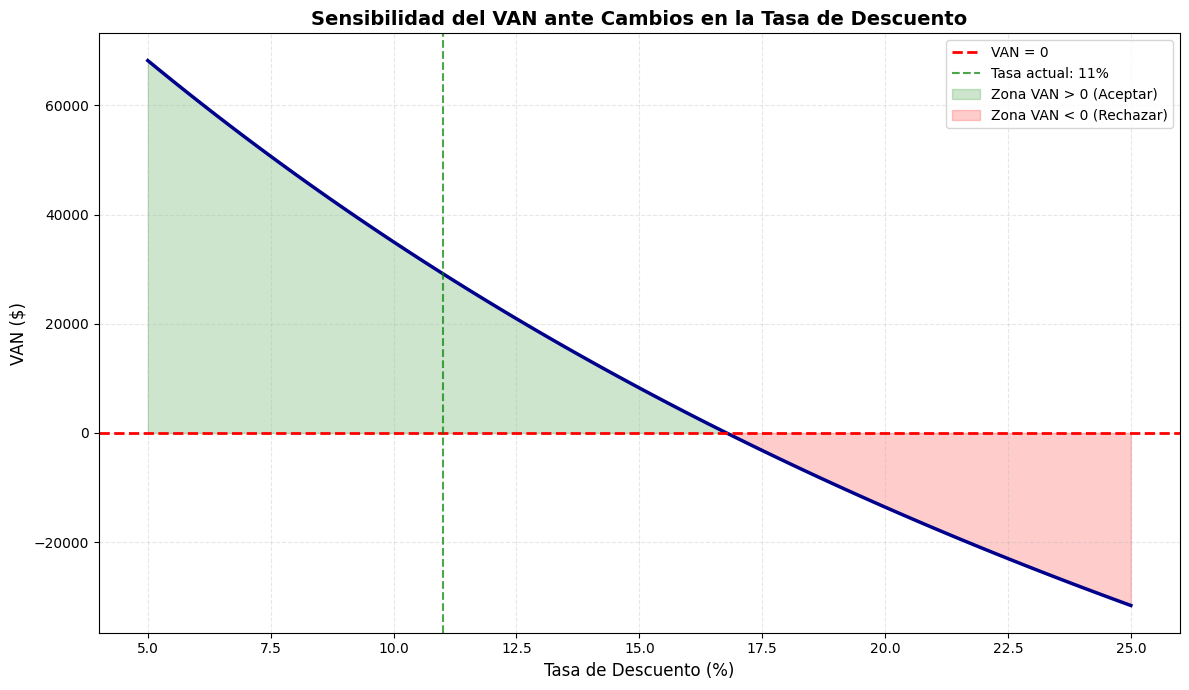


📊 Interpretación del gráfico:
   • Con la tasa actual (11%), el VAN es $29,185.70
   • A medida que aumenta la tasa de descuento, el VAN disminuye
   • Existe una tasa crítica donde VAN = 0 (esa tasa es la TIR)
   • Con tasas muy bajas, el proyecto es muy atractivo
   • Con tasas muy altas, el proyecto deja de ser viable


In [8]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS DE SENSIBILIDAD DEL VAN
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ANÁLISIS DE SENSIBILIDAD: ¿Cómo afecta la tasa de descuento al VAN?")
print("="*80)

# Rango de tasas de descuento
tasas_analisis = np.linspace(0.05, 0.25, 100)  # Del 5% al 25%
vans_resultantes = [npf.npv(r, flujos_maquina) for r in tasas_analisis]

# Graficar
plt.figure(figsize=(12, 7))
plt.plot(tasas_analisis * 100, vans_resultantes, linewidth=2.5, color='darkblue')
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='VAN = 0')
plt.axvline(tasa_descuento * 100, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'Tasa actual: {tasa_descuento:.0%}')

# Sombrear zonas
plt.fill_between(tasas_analisis * 100, 0, vans_resultantes, 
                 where=(np.array(vans_resultantes)>=0), alpha=0.2, color='green', 
                 label='Zona VAN > 0 (Aceptar)')
plt.fill_between(tasas_analisis * 100, vans_resultantes, 0, 
                 where=(np.array(vans_resultantes)<0), alpha=0.2, color='red', 
                 label='Zona VAN < 0 (Rechazar)')

plt.title('Sensibilidad del VAN ante Cambios en la Tasa de Descuento', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Descuento (%)', fontsize=12)
plt.ylabel('VAN ($)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n📊 Interpretación del gráfico:")
print(f"   • Con la tasa actual ({tasa_descuento:.0%}), el VAN es ${van_npf:,.2f}")
print(f"   • A medida que aumenta la tasa de descuento, el VAN disminuye")
print(f"   • Existe una tasa crítica donde VAN = 0 (esa tasa es la TIR)")
print(f"   • Con tasas muy bajas, el proyecto es muy atractivo")
print(f"   • Con tasas muy altas, el proyecto deja de ser viable")

---

<a id="tir"></a>

## 7️⃣ Tasa Interna de Retorno (TIR)

### 🔑 Concepto Fundamental

La **Tasa Interna de Retorno (TIR)** es la tasa de descuento que hace que el VAN sea exactamente cero. Representa el **rendimiento porcentual** que genera el proyecto.

### 📐 Definición Matemática

La TIR es el valor de $r$ que satisface:

$$
VAN = 0 = -I_0 + \sum_{t=1}^{n} \frac{FC_t}{(1 + TIR)^t}
$$

O de forma equivalente:

$$
I_0 = \sum_{t=1}^{n} \frac{FC_t}{(1 + TIR)^t}
$$

**Interpretación**: La inversión inicial es igual al valor presente de los flujos futuros descontados a la TIR.

### 💡 Criterio de Decisión

#### **TIR > r** (tasa de descuento) ✅
- El proyecto **rinde más** que el costo de oportunidad
- **Conviene aceptar** el proyecto
- Ejemplo: TIR = 18%, r = 12% → Rendimiento de 18% supera el costo del 12%

#### **TIR < r** ❌
- El proyecto **rinde menos** que el costo de oportunidad
- **Conviene rechazar** el proyecto
- Ejemplo: TIR = 8%, r = 12% → Mejor invertir en alternativa que rinde 12%

#### **TIR = r** ⚠️
- El proyecto es **indiferente**
- Genera exactamente el rendimiento mínimo requerido

### 🎯 Ventajas de la TIR

1. **Fácil de interpretar**: Es un porcentaje (rendimiento)
2. **No requiere tasa de descuento** para calcularla
3. **Permite comparar** proyectos de diferentes tamaños
4. **Intuitiva**: "Este proyecto rinde X% anual"

### ⚠️ Limitaciones de la TIR

1. **Asume reinversión a la TIR** (poco realista)
2. **Puede haber múltiples TIRs** con flujos no convencionales
3. **Puede no existir** si todos los flujos tienen el mismo signo
4. **Conflicto con VAN** en proyectos mutuamente excluyentes
5. **No muestra magnitud del valor creado** (solo %)

### 🔍 Relación TIR-VAN

La TIR es el punto donde la curva del VAN cruza el eje horizontal (VAN = 0).

```
VAN
 ↑
 │     ╱
 │    ╱
 │   ╱   VAN > 0 (si r < TIR)
 │  ╱
 │ ╱
─┼─────────────► r (tasa)
 │╲      TIR
 │ ╲
 │  ╲   VAN < 0 (si r > TIR)
 │   ╲
```

### 🧮 Cálculo con `numpy_financial`

```python
import numpy_financial as npf

# Flujos de caja
flujos = [-100000, 30000, 40000, 50000, 60000]

# Calcular TIR
tir = npf.irr(flujos)

print(f"TIR = {tir:.2%}")
```


---

<a id="caso-bursatil"></a>

## 📊 CASO DE ESTUDIO INTEGRAL: Inversión en Acciones de YPF

### 🎯 Contexto del Problema

Un inversor está considerando comprar acciones de YPF y mantenerlas durante 5 años. Necesita evaluar si la inversión es rentable.

**Datos disponibles:**
- Precios históricos de cierre de YPF (2019-2024)
- Tasa libre de riesgo: 4% anual
- Beta de YPF: 1.45
- Rendimiento esperado del mercado: 8.5% anual
- Cantidad de acciones a comprar: 1,000

**Objetivo:**
Calcular todas las métricas financieras (VAN, TIR, TIRM, IR, PRS, PRD) y determinar si conviene invertir.


In [9]:
# ═══════════════════════════════════════════════════════════════
# CASO DE ESTUDIO: INVERSIÓN EN ACCIONES YPF
# ═══════════════════════════════════════════════════════════════

print("="*80)
print("CASO DE ESTUDIO INTEGRAL: INVERSIÓN EN ACCIONES YPF")
print("="*80)

# ────────────────────────────────────────────────────────────
# ETAPA 1: RECOPILACIÓN Y PREPARACIÓN DE DATOS
# ────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("ETAPA 1: RECOPILACIÓN Y PREPARACIÓN DE DATOS")
print("="*80)

# Datos históricos de YPF (precios de cierre promedio anuales simulados)
años = np.array([0, 1, 2, 3, 4, 5])
precios_cierre = np.array([450, 520, 580, 650, 720, 800])  # Precio por acción en pesos

# Parámetros de la inversión
cantidad_acciones = 1000
rf = 0.04   # Tasa libre de riesgo: 4%
beta = 1.45
rm = 0.085  # Rendimiento esperado del mercado: 8.5%

# Crear DataFrame
df_ypf = pd.DataFrame({
    'Año': años,
    'Precio Promedio Cierre': precios_cierre,
    'Cantidad Acciones': cantidad_acciones
})

print("\n📊 DATOS DEL PROYECTO:")
print(df_ypf.to_string(index=False))

print(f"\n💼 PARÁMETROS DE MERCADO:")
print(f"   • Tasa libre de riesgo (rf):        {rf:.2%}")
print(f"   • Beta de YPF:                      {beta:.2f}")
print(f"   • Rendimiento esperado mercado (rm): {rm:.2%}")

# ────────────────────────────────────────────────────────────
# ETAPA 2: DETERMINACIÓN DE LA TASA DE DESCUENTO (CAPM)
# ────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("ETAPA 2: CÁLCULO DE TASA DE DESCUENTO (CAPM)")
print("="*80)

# Fórmula CAPM: r = rf + β(rm - rf)
tasa_descuento_capm = rf + beta * (rm - rf)

print(f"\nFórmula CAPM:")
print(f"r = rf + β × (rm - rf)")
print(f"r = {rf:.2%} + {beta:.2f} × ({rm:.2%} - {rf:.2%})")
print(f"r = {rf:.2%} + {beta:.2f} × {(rm - rf):.2%}")
print(f"r = {tasa_descuento_capm:.4%}")

print(f"\n💡 INTERPRETACIÓN:")
print(f"   La tasa de descuento ajustada por riesgo para YPF es {tasa_descuento_capm:.2%}")
print(f"   Esta tasa refleja el riesgo sistemático (beta = {beta}) de la acción.")

# ────────────────────────────────────────────────────────────
# ETAPA 3: CONSTRUCCIÓN DE FLUJOS DE CAJA
# ────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("ETAPA 3: CONSTRUCCIÓN DE FLUJOS DE CAJA")
print("="*80)

# Inversión inicial (año 0)
inversion_inicial_ypf = -df_ypf.loc[0, 'Precio Promedio Cierre'] * cantidad_acciones

# Flujos intermedios: cambios en el valor de la inversión
df_ypf['Flujo'] = 0
df_ypf.loc[0, 'Flujo'] = inversion_inicial_ypf

# Calcular cambios año a año
for i in range(1, len(df_ypf) - 1):
    cambio_precio = df_ypf.loc[i, 'Precio Promedio Cierre'] - df_ypf.loc[i-1, 'Precio Promedio Cierre']
    df_ypf.loc[i, 'Flujo'] = cambio_precio * cantidad_acciones

# Flujo final (año 5): venta total de acciones
df_ypf.loc[5, 'Flujo'] = df_ypf.loc[5, 'Precio Promedio Cierre'] * cantidad_acciones

print("\n📈 ESTRUCTURA DE FLUJOS DE CAJA:")
print(df_ypf.to_string(index=False))

print(f"\n💰 EXPLICACIÓN DE FLUJOS:")
print(f"   • Año 0: Inversión inicial de ${abs(inversion_inicial_ypf):,.2f} (compra de acciones)")
print(f"   • Años 1-4: Cambios en el valor de mercado de la inversión")
print(f"   • Año 5: Venta total de las acciones a ${df_ypf.loc[5, 'Precio Promedio Cierre']:.2f} c/u")

flujos_ypf = df_ypf['Flujo'].tolist()

# ────────────────────────────────────────────────────────────
# ETAPA 4: CÁLCULO DE MÉTRICAS FINANCIERAS
# ────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("ETAPA 4: CÁLCULO DE MÉTRICAS FINANCIERAS")
print("="*80)

# Usar el template definido anteriormente
resultados_ypf = evaluar_proyecto(
    flujos=flujos_ypf,
    tasa_descuento_anual=tasa_descuento_capm,
    nombre_proyecto="Inversión en Acciones YPF"
)

CASO DE ESTUDIO INTEGRAL: INVERSIÓN EN ACCIONES YPF

ETAPA 1: RECOPILACIÓN Y PREPARACIÓN DE DATOS

📊 DATOS DEL PROYECTO:
 Año  Precio Promedio Cierre  Cantidad Acciones
   0                     450               1000
   1                     520               1000
   2                     580               1000
   3                     650               1000
   4                     720               1000
   5                     800               1000

💼 PARÁMETROS DE MERCADO:
   • Tasa libre de riesgo (rf):        4.00%
   • Beta de YPF:                      1.45
   • Rendimiento esperado mercado (rm): 8.50%

ETAPA 2: CÁLCULO DE TASA DE DESCUENTO (CAPM)

Fórmula CAPM:
r = rf + β × (rm - rf)
r = 4.00% + 1.45 × (8.50% - 4.00%)
r = 4.00% + 1.45 × 4.50%
r = 10.5250%

💡 INTERPRETACIÓN:
   La tasa de descuento ajustada por riesgo para YPF es 10.53%
   Esta tasa refleja el riesgo sistemático (beta = 1.45) de la acción.

ETAPA 3: CONSTRUCCIÓN DE FLUJOS DE CAJA

📈 ESTRUCTURA DE FLUJOS DE CAJA

/home/alexballera/Documents/uba/laboratorio-tgad-fce/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


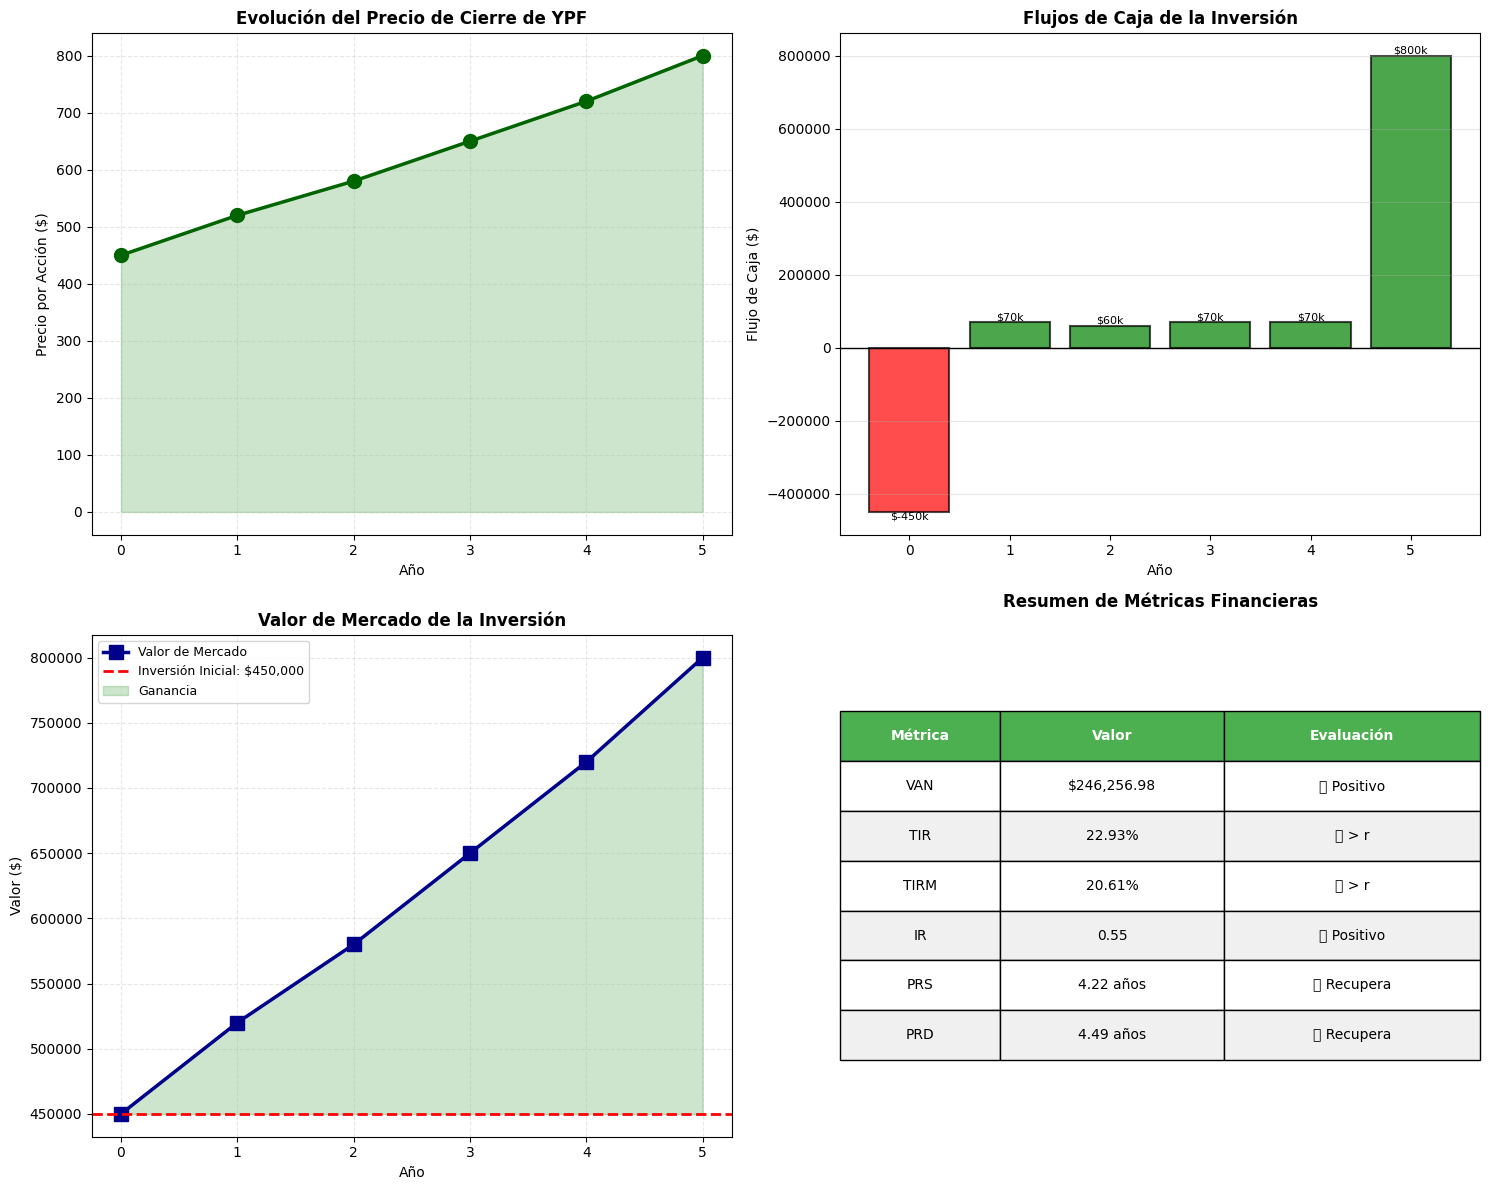


VISUALIZACIONES COMPLETADAS

📊 Los gráficos muestran:
   1. Evolución del precio de la acción de YPF
   2. Distribución temporal de flujos de caja
   3. Crecimiento del valor de mercado de la inversión
   4. Resumen consolidado de todas las métricas calculadas


In [10]:
# ═══════════════════════════════════════════════════════════════
# VISUALIZACIONES ADICIONALES DEL CASO YPF
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ────────────────────────────────────────────────────────────
# Gráfico 1: Evolución del Precio de la Acción
# ────────────────────────────────────────────────────────────

ax1 = axes[0, 0]
ax1.plot(df_ypf['Año'], df_ypf['Precio Promedio Cierre'], 
         marker='o', linewidth=2.5, markersize=10, color='darkgreen')
ax1.fill_between(df_ypf['Año'], 0, df_ypf['Precio Promedio Cierre'], 
                 alpha=0.2, color='green')
ax1.set_title('Evolución del Precio de Cierre de YPF', fontsize=12, fontweight='bold')
ax1.set_xlabel('Año', fontsize=10)
ax1.set_ylabel('Precio por Acción ($)', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(años)

# ────────────────────────────────────────────────────────────
# Gráfico 2: Flujos de Caja del Proyecto
# ────────────────────────────────────────────────────────────

ax2 = axes[0, 1]
colores_flujos = ['red' if f < 0 else 'green' for f in flujos_ypf]
ax2.bar(años, flujos_ypf, color=colores_flujos, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Flujos de Caja de la Inversión', fontsize=12, fontweight='bold')
ax2.set_xlabel('Año', fontsize=10)
ax2.set_ylabel('Flujo de Caja ($)', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(años)

# Anotar valores
for i, (año, flujo) in enumerate(zip(años, flujos_ypf)):
    ax2.text(año, flujo, f'${flujo/1000:.0f}k', 
             ha='center', va='bottom' if flujo > 0 else 'top', fontsize=8)

# ────────────────────────────────────────────────────────────
# Gráfico 3: Valor de la Inversión (Acumulado)
# ────────────────────────────────────────────────────────────

ax3 = axes[1, 0]
valor_inversion = df_ypf['Precio Promedio Cierre'] * cantidad_acciones

ax3.plot(años, valor_inversion, marker='s', linewidth=2.5, 
         markersize=10, color='darkblue', label='Valor de Mercado')
ax3.axhline(abs(inversion_inicial_ypf), color='red', linestyle='--', 
            linewidth=2, label=f'Inversión Inicial: ${abs(inversion_inicial_ypf):,.0f}')
ax3.fill_between(años, abs(inversion_inicial_ypf), valor_inversion, 
                 where=(valor_inversion >= abs(inversion_inicial_ypf)),
                 alpha=0.2, color='green', label='Ganancia')
ax3.set_title('Valor de Mercado de la Inversión', fontsize=12, fontweight='bold')
ax3.set_xlabel('Año', fontsize=10)
ax3.set_ylabel('Valor ($)', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(años)

# ────────────────────────────────────────────────────────────
# Gráfico 4: Resumen de Métricas
# ────────────────────────────────────────────────────────────

ax4 = axes[1, 1]
ax4.axis('off')

# Crear tabla de resumen
metricas_nombres = ['VAN', 'TIR', 'TIRM', 'IR', 'PRS', 'PRD']
metricas_valores = []
metricas_interpretacion = []

for metrica in metricas_nombres:
    valor = resultados_ypf[metrica]
    if metrica == 'VAN':
        metricas_valores.append(f"${valor:,.2f}")
        metricas_interpretacion.append("✅ Positivo" if valor > 0 else "❌ Negativo")
    elif metrica in ['TIR', 'TIRM']:
        if valor is not None:
            metricas_valores.append(f"{valor:.2%}")
            metricas_interpretacion.append("✅ > r" if valor > tasa_descuento_capm else "❌ < r")
        else:
            metricas_valores.append("N/A")
            metricas_interpretacion.append("⚠️ No calculable")
    elif metrica == 'IR':
        metricas_valores.append(f"{valor:.2f}")
        metricas_interpretacion.append("✅ Positivo" if valor > 0 else "❌ Negativo")
    else:  # PRS, PRD
        if valor is not None:
            metricas_valores.append(f"{valor:.2f} años")
            metricas_interpretacion.append("✅ Recupera")
        else:
            metricas_valores.append("N/A")
            metricas_interpretacion.append("❌ No recupera")

# Crear tabla
tabla_data = list(zip(metricas_nombres, metricas_valores, metricas_interpretacion))
tabla = ax4.table(cellText=tabla_data, 
                  colLabels=['Métrica', 'Valor', 'Evaluación'],
                  cellLoc='center', loc='center',
                  colWidths=[0.25, 0.35, 0.4])
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2.5)

# Estilo de tabla
for (i, j), cell in tabla.get_celld().items():
    if i == 0:
        cell.set_facecolor('#4CAF50')
        cell.set_text_props(weight='bold', color='white')
    elif i % 2 == 0:
        cell.set_facecolor('#f0f0f0')

ax4.set_title('Resumen de Métricas Financieras', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZACIONES COMPLETADAS")
print("="*80)
print("\n📊 Los gráficos muestran:")
print("   1. Evolución del precio de la acción de YPF")
print("   2. Distribución temporal de flujos de caja")
print("   3. Crecimiento del valor de mercado de la inversión")
print("   4. Resumen consolidado de todas las métricas calculadas")

---

<a id="checklist"></a>

## ✅ Checklist de Verificación para Análisis de Inversiones

Utiliza este checklist para asegurar que has completado todos los pasos en tu evaluación:

### 📋 Fase de Preparación

- [ ] **Contexto claro**: ¿Definiste el objetivo del proyecto?
- [ ] **Inversión inicial**: ¿Identificaste el desembolso en t=0?
- [ ] **Flujos proyectados**: ¿Estimaste todos los flujos operativos?
- [ ] **Horizonte temporal**: ¿Definiste la duración del proyecto?
- [ ] **Valor residual**: ¿Consideraste recuperación al final (si aplica)?

### 📊 Fase de Tasa de Descuento

- [ ] **Tasa libre de riesgo**: ¿Identificaste rf?
- [ ] **Evaluación de riesgo**: ¿Calculaste beta o estimaste prima de riesgo?
- [ ] **CAPM o WACC**: ¿Determinaste la tasa de descuento apropiada?
- [ ] **Ajuste de frecuencia**: ¿Convertiste anual a mensual/trimestral si es necesario?
- [ ] **Justificación**: ¿Documentaste por qué usaste esa tasa?

### 🔢 Fase de Cálculo

- [ ] **Estructura de datos**: ¿Armaste la lista/DataFrame de flujos correctamente?
- [ ] **Signos correctos**: ¿La inversión inicial es negativa?
- [ ] **VAN calculado**: ¿Usaste `npf.npv(r, flujos)`?
- [ ] **TIR calculada**: ¿Usaste `npf.irr(flujos)`?
- [ ] **TIRM calculada**: ¿Usaste `npf.mirr(flujos, r, r)`?
- [ ] **IR calculado**: ¿Dividiste VAN / Inversión Inicial?
- [ ] **PRS calculado**: ¿Sumaste flujos hasta recuperar inversión?
- [ ] **PRD calculado**: ¿Descontaste flujos antes de acumular?

### 🎯 Fase de Interpretación

- [ ] **VAN > 0**: ¿Verificaste si el proyecto crea valor?
- [ ] **TIR > r**: ¿Comparaste rendimiento vs costo de capital?
- [ ] **Consistencia**: ¿Las métricas apuntan en la misma dirección?
- [ ] **Conflictos**: ¿Identificaste contradicciones entre métricas?
- [ ] **Análisis de sensibilidad**: ¿Probaste escenarios alternativos?

### 📈 Fase de Visualización

- [ ] **Gráfico de flujos**: ¿Mostraste la distribución temporal?
- [ ] **Gráfico de recuperación**: ¿Ilustraste PRS y PRD?
- [ ] **Sensibilidad del VAN**: ¿Graficaste VAN vs tasa de descuento?
- [ ] **Títulos y etiquetas**: ¿Todo está en español?
- [ ] **Leyendas claras**: ¿Se entiende qué representa cada curva?

### 📝 Fase de Decisión

- [ ] **Recomendación clara**: ¿Aceptar/Rechazar/Revisar?
- [ ] **Justificación**: ¿Fundamentaste la decisión con las métricas?
- [ ] **Consideraciones adicionales**: ¿Mencionaste factores cualitativos?
- [ ] **Próximos pasos**: ¿Definiste acciones a seguir?

---


<a id="tabla-formulas"></a>

## 📐 Tabla de Fórmulas - Referencia Rápida

### 🔹 Valor del Dinero en el Tiempo

| Concepto | Fórmula | Variables |
|----------|---------|-----------|
| **Valor Futuro** | $VF = VP \times (1 + i)^n$ | VP: valor presente, i: tasa, n: períodos |
| **Valor Presente** | $VP = \frac{VF}{(1 + i)^n}$ | VF: valor futuro, i: tasa, n: períodos |

### 🔹 Tasas de Interés

| Concepto | Fórmula | Observación |
|----------|---------|-------------|
| **Tasa Proporcional** | $i_{\text{período}} = TNA \times \frac{\text{días}}{365}$ | Sin capitalización |
| **Tasa Efectiva Anual (TEA)** | $TEA = \left(1 + \frac{TNA}{m}\right)^m - 1$ | m: capitalizaciones/año |
| **Equivalencia entre períodos** | $i_{t_2} = (1 + i_{t_1})^{t_2/t_1} - 1$ | Con capitalización |

### 🔹 Métricas de Evaluación de Proyectos

| Métrica | Fórmula | Criterio de Aceptación |
|---------|---------|----------------------|
| **VAN** | $VAN = \sum_{t=0}^{n} \frac{FC_t}{(1 + r)^t}$ | VAN > 0 |
| **TIR** | $0 = \sum_{t=0}^{n} \frac{FC_t}{(1 + TIR)^t}$ | TIR > r |
| **TIRM** | $TIRM = \left(\frac{VF_{\text{positivos}}}{VP_{\text{negativos}}}\right)^{1/n} - 1$ | TIRM > r |
| **IR** | $IR = \frac{VAN}{I_0}$ | IR > 0 |
| **PRS** | Acumular flujos hasta $\sum FC_t \geq I_0$ | PRS < límite aceptable |
| **PRD** | Acumular flujos descontados hasta $\sum \frac{FC_t}{(1+r)^t} \geq 0$ | PRD < límite aceptable |

### 🔹 Costo de Capital

| Modelo | Fórmula | Aplicación |
|--------|---------|------------|
| **CAPM** | $r = r_f + \beta(r_m - r_f)$ | Proyectos con riesgo sistemático |
| **WACC** | $WACC = \frac{E}{V} r_e + \frac{D}{V} r_d (1 - T_c)$ | Proyectos con deuda y capital |

**Notación:**
- $FC_t$: Flujo de caja en período t
- $r$: Tasa de descuento
- $I_0$: Inversión inicial
- $n$: Número de períodos
- $r_f$: Tasa libre de riesgo
- $\beta$: Beta (medida de riesgo sistemático)
- $r_m$: Rendimiento esperado del mercado
- $E$: Capital propio (equity)
- $D$: Deuda (debt)
- $V$: Valor total (E + D)
- $T_c$: Tasa impositiva

---


<a id="referencias"></a>

## 📚 Referencias y Recursos Adicionales

### 📖 Bibliografía Recomendada

1. **Brealey, R., Myers, S., & Allen, F.** (2020). *Principios de Finanzas Corporativas* (13ª ed.). McGraw-Hill.
   - Capítulos 2-6: Valor del dinero en el tiempo y evaluación de proyectos

2. **Ross, S., Westerfield, R., & Jordan, B.** (2018). *Fundamentos de Finanzas Corporativas* (11ª ed.). McGraw-Hill.
   - Capítulos 8-10: Flujos de caja y técnicas de presupuestación de capital

3. **Sapag Chain, N., & Sapag Chain, R.** (2014). *Preparación y Evaluación de Proyectos* (6ª ed.). McGraw-Hill.
   - Referencia latinoamericana clásica sobre evaluación de proyectos

### 🌐 Recursos en Línea

- **numpy-financial Documentation**: https://numpy.org/numpy-financial/
  - Documentación oficial de las funciones financieras de NumPy

- **Investopedia - Finance Formulas**: https://www.investopedia.com/
  - Diccionario financiero con ejemplos prácticos

- **Corporate Finance Institute (CFI)**: https://corporatefinanceinstitute.com/
  - Recursos gratuitos sobre finanzas corporativas

### 🛠️ Herramientas Complementarias

- **Microsoft Excel**: Funciones financieras (VAN, TIR, TIRM)
- **Python Libraries**:
  - `numpy_financial`: Cálculos financieros
  - `pandas`: Manejo de datos temporales
  - `matplotlib` / `seaborn`: Visualización
  - `scipy.optimize`: Optimización financiera

### 📊 Datasets para Práctica

- **Yahoo Finance**: Precios históricos de acciones
- **BCRA (Banco Central)**: Tasas de interés argentinas
- **INDEC**: Inflación y datos macroeconómicos argentinos

---

## 🎓 Conclusión

Esta guía completa te proporciona:

✅ **Fundamentos teóricos** sólidos sobre valor del dinero en el tiempo  
✅ **Marco metodológico** estructurado (5 Pilares del Análisis)  
✅ **Workflow sistemático** de evaluación de inversiones  
✅ **Herramientas prácticas**: VAN, TIR, TIRM, IR, PRS, PRD  
✅ **Template reutilizable** para análisis de proyectos  
✅ **Casos de estudio** con datos reales  
✅ **Visualizaciones** profesionales  
✅ **Checklist** de verificación completo

**Diferencia clave con guías de integrales:**

En matemáticas (integrales), existe un **proceso paso a paso** mecánico y predecible. En finanzas, el análisis es **iterativo y contextual**: los mismos datos pueden llevar a decisiones diferentes según el contexto, riesgo y objetivos del inversor.

**Recuerda**: Las métricas financieras son **herramientas de apoyo**, no fórmulas mágicas. La decisión final debe considerar:
- Análisis cuantitativo (métricas)
- Análisis cualitativo (riesgo, estrategia, mercado)
- Restricciones operativas (capital, tiempo, recursos)

---

**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**  
**Facultad de Ciencias Económicas - Universidad de Buenos Aires**

---

💡 **Tip final**: Guarda esta guía como referencia y adapta el template genérico a tus propios proyectos de inversión. ¡Éxitos en tus análisis financieros!

In [11]:
# Definición de Funciones Financieras Básicas

def tasa_proporcion(TNA, dias_periodo):
    """
    Calcula tasa de período usando fórmula de proporción (sin capitalización).
    
    Args:
        TNA (float): Tasa Nominal Anual (decimal, ej: 0.40 para 40%)
        dias_periodo (int): Días del período
    
    Returns:
        float: Tasa proporcional del período
    """
    return TNA * (dias_periodo / 365)

def tasa_equivalencia(i_t1, t2, t1):
    """
    Calcula tasa equivalente entre períodos (con capitalización).
    
    Args:
        i_t1 (float): Tasa del período t1 (decimal)
        t2 (int): Período destino (días)
        t1 (int): Período origen (días)
    
    Returns:
        float: Tasa equivalente para el período t2
    """
    return (1 + i_t1) ** (t2 / t1) - 1

def TNA_a_TEA(TNA, m):
    """
    Convierte TNA a TEA considerando capitalización.
    
    Args:
        TNA (float): Tasa Nominal Anual (decimal)
        m (int): Número de capitalizaciones por año
    
    Returns:
        float: Tasa Efectiva Anual
    """
    return (1 + TNA / m) ** m - 1

def valor_futuro(vp, i, n):
    """
    Calcula el valor futuro con capitalización compuesta.
    
    Args:
        vp (float): Valor Presente
        i (float): Tasa de interés por período (decimal)
        n (int): Número de períodos
    
    Returns:
        float: Valor Futuro
    """
    return vp * (1 + i) ** n

def valor_presente(vf, i, n):
    """
    Calcula el valor presente descontando flujos futuros.
    
    Args:
        vf (float): Valor Futuro
        i (float): Tasa de descuento por período (decimal)
        n (int): Número de períodos
    
    Returns:
        float: Valor Presente
    """
    return vf / ((1 + i) ** n)

print("✅ Funciones financieras básicas definidas correctamente")

✅ Funciones financieras básicas definidas correctamente


### 📊 Ejemplo Práctico: Oferta de Crédito Bancario

**Contexto:**

El Banco Santander ofrece un crédito con una **TNA del 40%** con capitalización mensual.

**Preguntas:**
1. ¿Cuál es la tasa proporcional a 90 días?
2. ¿Cuál es la tasa efectiva mensual?
3. ¿Cuál es la TEA real del crédito?
4. Si pedís $100,000, ¿cuánto deberás al cabo de 1 año?

In [12]:
# EJEMPLO: Análisis de Oferta de Crédito Bancario

print("="*70)
print("ANÁLISIS DE OFERTA DE CRÉDITO - BANCO SANTANDER")
print("="*70)

# Datos del crédito
TNA_credito = 0.40  # 40% anual nominal
dias_trimestre = 90
monto_credito = 100000

# 1. Tasa proporcional a 90 días (SIN capitalización)
tasa_90_dias_prop = tasa_proporcion(TNA_credito, dias_trimestre)

print(f"\n1️⃣ FÓRMULA DE PROPORCIÓN (sin capitalización):")
print(f"   TNA declarada:                    {TNA_credito:.2%}")
print(f"   Tasa proporcional a 90 días:      {tasa_90_dias_prop:.4%}")
print(f"   (Simplemente: 40% × 90/365)")

# 2. Tasa efectiva mensual (CON capitalización)
tasa_mensual_efectiva = tasa_equivalencia(tasa_90_dias_prop, 30, dias_trimestre)

print(f"\n2️⃣ FÓRMULA DE EQUIVALENCIA (con capitalización):")
print(f"   Tasa efectiva mensual:            {tasa_mensual_efectiva:.4%}")
print(f"   (Desde tasa trimestral: (1 + i₉₀)^(30/90) - 1)")

# 3. TEA real del crédito
TEA_credito = TNA_a_TEA(TNA_credito, 12)

print(f"\n3️⃣ TASA EFECTIVA ANUAL (TEA):")
print(f"   TEA real del crédito:             {TEA_credito:.4%}")
print(f"   Diferencia vs TNA:                {(TEA_credito - TNA_credito):.4%}")
print(f"   ⚠️ La TEA es MAYOR que la TNA por el efecto de capitalización")

# 4. Deuda al cabo de 1 año
deuda_final = valor_futuro(monto_credito, tasa_mensual_efectiva, 12)
intereses_pagados = deuda_final - monto_credito

print(f"\n4️⃣ PROYECCIÓN DEL CRÉDITO:")
print(f"   Monto inicial solicitado:         ${monto_credito:,.2f}")
print(f"   Deuda al cabo de 1 año:           ${deuda_final:,.2f}")
print(f"   Intereses totales pagados:        ${intereses_pagados:,.2f}")
print(f"   Carga financiera real:            {(intereses_pagados/monto_credito):.2%}")

print("\n" + "="*70)
print("💡 INTERPRETACIÓN ECONÓMICA:")
print("="*70)
print(f"   • El banco declara una TNA del {TNA_credito:.0%}, pero la tasa REAL")
print(f"     que pagarás es la TEA de {TEA_credito:.2%} debido a la capitalización.")
print(f"   • Esto significa que por cada $100,000 que pidas, terminarás")
print(f"     pagando ${intereses_pagados:,.2f} adicionales en intereses.")
print(f"   • Tasa mensual efectiva: {tasa_mensual_efectiva:.4%}")
print("="*70)

ANÁLISIS DE OFERTA DE CRÉDITO - BANCO SANTANDER

1️⃣ FÓRMULA DE PROPORCIÓN (sin capitalización):
   TNA declarada:                    40.00%
   Tasa proporcional a 90 días:      9.8630%
   (Simplemente: 40% × 90/365)

2️⃣ FÓRMULA DE EQUIVALENCIA (con capitalización):
   Tasa efectiva mensual:            3.1851%
   (Desde tasa trimestral: (1 + i₉₀)^(30/90) - 1)

3️⃣ TASA EFECTIVA ANUAL (TEA):
   TEA real del crédito:             48.2126%
   Diferencia vs TNA:                8.2126%
   ⚠️ La TEA es MAYOR que la TNA por el efecto de capitalización

4️⃣ PROYECCIÓN DEL CRÉDITO:
   Monto inicial solicitado:         $100,000.00
   Deuda al cabo de 1 año:           $145,682.05
   Intereses totales pagados:        $45,682.05
   Carga financiera real:            45.68%

💡 INTERPRETACIÓN ECONÓMICA:
   • El banco declara una TNA del 40%, pero la tasa REAL
     que pagarás es la TEA de 48.21% debido a la capitalización.
   • Esto significa que por cada $100,000 que pidas, terminarás
     pagando $4

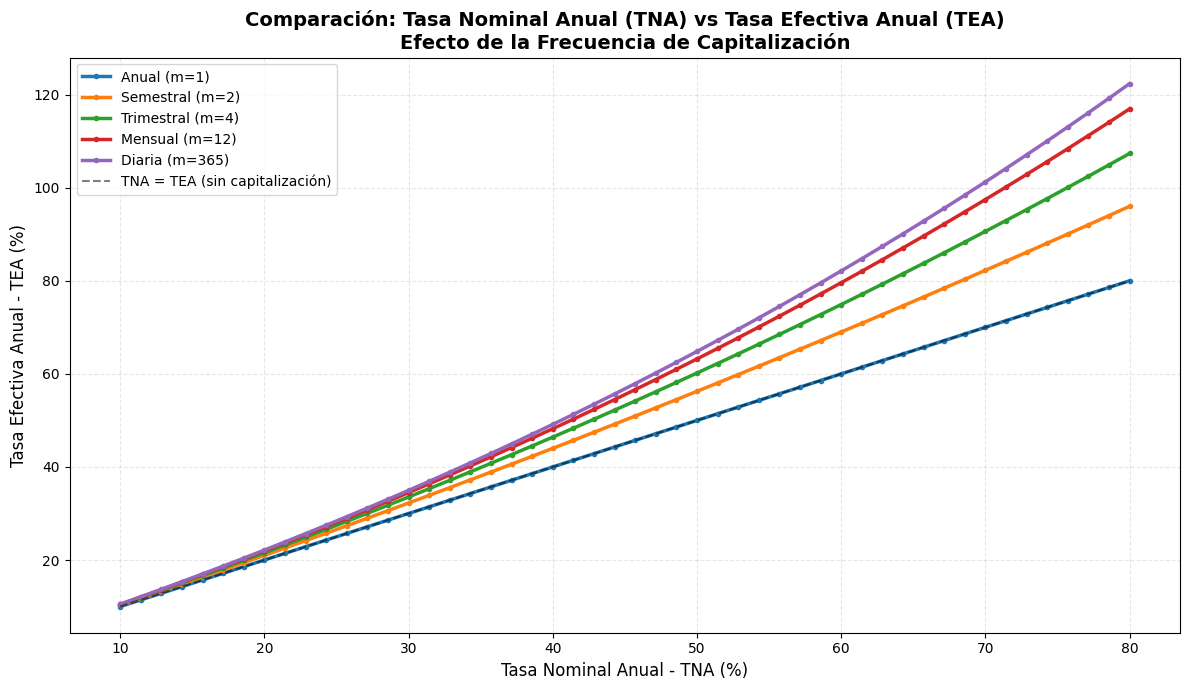


📊 Observaciones del gráfico:
   • A mayor frecuencia de capitalización (m), mayor es la TEA
   • La diferencia entre TNA y TEA es más notoria con tasas altas
   • Capitalización diaria (m=365) genera la TEA más alta
   • Siempre: TEA ≥ TNA (con igualdad solo si m=1)


In [13]:
# Visualización Comparativa: TNA vs TEA

TNA_valores = np.linspace(0.10, 0.80, 50)  # TNA del 10% al 80%
capitalizaciones = [1, 2, 4, 12, 365]  # Anual, Semestral, Trimestral, Mensual, Diaria
labels = ['Anual', 'Semestral', 'Trimestral', 'Mensual', 'Diaria']

plt.figure(figsize=(12, 7))

for m, label in zip(capitalizaciones, labels):
    TEA_valores = [(1 + TNA/m)**m - 1 for TNA in TNA_valores]
    plt.plot(TNA_valores * 100, np.array(TEA_valores) * 100, 
             linewidth=2.5, label=f'{label} (m={m})', marker='o', markersize=3)

# Línea de referencia (TNA = TEA, sin capitalización)
plt.plot(TNA_valores * 100, TNA_valores * 100, 'k--', linewidth=1.5, 
         label='TNA = TEA (sin capitalización)', alpha=0.5)

plt.title('Comparación: Tasa Nominal Anual (TNA) vs Tasa Efectiva Anual (TEA)\n'
          'Efecto de la Frecuencia de Capitalización', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tasa Nominal Anual - TNA (%)', fontsize=12)
plt.ylabel('Tasa Efectiva Anual - TEA (%)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n📊 Observaciones del gráfico:")
print("   • A mayor frecuencia de capitalización (m), mayor es la TEA")
print("   • La diferencia entre TNA y TEA es más notoria con tasas altas")
print("   • Capitalización diaria (m=365) genera la TEA más alta")
print("   • Siempre: TEA ≥ TNA (con igualdad solo si m=1)")

---

<a id="capitalizacion-descuento"></a>

## 3️⃣ Capitalización y Descuento

### 🔑 Conceptos Fundamentales

#### **Capitalización Compuesta**

Es el proceso de **proyectar un monto presente hacia el futuro**, considerando que los intereses generados en cada período se suman al capital y generan nuevos intereses.

$$
VF = VP \times (1 + i)^n
$$

**Características:**
- Los intereses se **reinvierten** automáticamente
- Crece **exponencialmente** (no linealmente)
- Es la base del **interés compuesto**

#### **Descuento (Actualización)**

Es el proceso **inverso**: traer un monto futuro al presente para poder compararlo con otras alternativas.

$$
VP = \frac{VF}{(1 + i)^n}
$$

**Características:**
- Permite **comparar** flujos de caja en diferentes momentos
- Es esencial para **evaluar proyectos de inversión**
- La tasa $i$ se llama **tasa de descuento**

### 💡 Diferencias Clave

| Concepto | Capitalización | Descuento |
|----------|---------------|----------|
| **Dirección temporal** | Presente → Futuro | Futuro → Presente |
| **Fórmula** | $VF = VP \times (1+i)^n$ | $VP = VF / (1+i)^n$ |
| **Pregunta que responde** | ¿Cuánto tendré? | ¿Cuánto vale hoy? |
| **Aplicación** | Ahorro, inversión | Evaluación de proyectos |
| **Tasa usada** | Tasa de rendimiento | Tasa de descuento |

### 📊 Relación Matemática

Son **operaciones inversas**:

$$
\text{Capitalizar} \rightarrow VF = VP \times (1+i)^n
$$

$$
\text{Descontar} \rightarrow VP = VF \times (1+i)^{-n}
$$

Verificación: Si capitalizamos $VP$ y luego descontamos $VF$, recuperamos $VP$:

$$
VP \xrightarrow{\text{capitalizar}} VF \xrightarrow{\text{descontar}} VP
$$

In [14]:
# EJEMPLO INTEGRADO: Capitalización y Descuento

print("="*70)
print("EJEMPLO INTEGRADO: CAPITALIZACIÓN Y DESCUENTO")
print("="*70)

# Parámetros
capital_inicial = 50000
tasa_anual = 0.12  # 12% anual
años_horizonte = 5

print(f"\n📌 CONTEXTO DEL PROBLEMA:")
print(f"   Tenés ${capital_inicial:,.2f} para invertir.")
print(f"   Tasa de rendimiento esperada: {tasa_anual:.2%} anual")
print(f"   Horizonte temporal: {años_horizonte} años")

# PARTE 1: CAPITALIZACIÓN
print(f"\n" + "="*70)
print("PARTE 1: CAPITALIZACIÓN (¿Cuánto tendré en el futuro?)")
print("="*70)

vf_calculado = valor_futuro(capital_inicial, tasa_anual, años_horizonte)
intereses_ganados = vf_calculado - capital_inicial

print(f"\nFórmula: VF = VP × (1 + i)^n")
print(f"VF = ${capital_inicial:,.2f} × (1 + {tasa_anual})^{años_horizonte}")
print(f"VF = ${vf_calculado:,.2f}")
print(f"\n💰 Interpretación:")
print(f"   • Tu inversión crecerá a ${vf_calculado:,.2f} en {años_horizonte} años")
print(f"   • Ganarás ${intereses_ganados:,.2f} en intereses")
print(f"   • Rendimiento total: {(intereses_ganados/capital_inicial):.2%}")

# PARTE 2: DESCUENTO
print(f"\n" + "="*70)
print("PARTE 2: DESCUENTO (¿Cuánto vale hoy un monto futuro?)")
print("="*70)

monto_futuro_prometido = 90000
vp_del_futuro = valor_presente(monto_futuro_prometido, tasa_anual, años_horizonte)

print(f"\nSupongamos que te prometen ${monto_futuro_prometido:,.2f} en {años_horizonte} años.")
print(f"¿Cuál es el valor PRESENTE (hoy) de esa promesa?")
print(f"\nFórmula: VP = VF / (1 + i)^n")
print(f"VP = ${monto_futuro_prometido:,.2f} / (1 + {tasa_anual})^{años_horizonte}")
print(f"VP = ${vp_del_futuro:,.2f}")
print(f"\n💰 Interpretación:")
print(f"   • Recibir ${monto_futuro_prometido:,.2f} en {años_horizonte} años equivale a")
print(f"     recibir ${vp_del_futuro:,.2f} HOY (al {tasa_anual:.0%} de descuento)")
print(f"   • Si te ofrecen menos de ${vp_del_futuro:,.2f} hoy, mejor esperar")

# PARTE 3: VERIFICACIÓN DE INVERSAS
print(f"\n" + "="*70)
print("PARTE 3: VERIFICACIÓN (Capitalizar y luego Descontar)")
print("="*70)

vp_verificado = valor_presente(vf_calculado, tasa_anual, años_horizonte)
error = abs(vp_verificado - capital_inicial)

print(f"\n1. Capital inicial:              ${capital_inicial:,.2f}")
print(f"2. Capitalizado a {años_horizonte} años:     ${vf_calculado:,.2f}")
print(f"3. Descontado nuevamente:        ${vp_verificado:,.2f}")
print(f"4. Error de redondeo:            ${error:.10f}")
print(f"\n✅ Las operaciones son INVERSAS: capitalizamos y descontamos,")
print(f"   recuperando el valor original (salvo error de redondeo).")

print("\n" + "="*70)

EJEMPLO INTEGRADO: CAPITALIZACIÓN Y DESCUENTO

📌 CONTEXTO DEL PROBLEMA:
   Tenés $50,000.00 para invertir.
   Tasa de rendimiento esperada: 12.00% anual
   Horizonte temporal: 5 años

PARTE 1: CAPITALIZACIÓN (¿Cuánto tendré en el futuro?)

Fórmula: VF = VP × (1 + i)^n
VF = $50,000.00 × (1 + 0.12)^5
VF = $88,117.08

💰 Interpretación:
   • Tu inversión crecerá a $88,117.08 en 5 años
   • Ganarás $38,117.08 en intereses
   • Rendimiento total: 76.23%

PARTE 2: DESCUENTO (¿Cuánto vale hoy un monto futuro?)

Supongamos que te prometen $90,000.00 en 5 años.
¿Cuál es el valor PRESENTE (hoy) de esa promesa?

Fórmula: VP = VF / (1 + i)^n
VP = $90,000.00 / (1 + 0.12)^5
VP = $51,068.42

💰 Interpretación:
   • Recibir $90,000.00 en 5 años equivale a
     recibir $51,068.42 HOY (al 12% de descuento)
   • Si te ofrecen menos de $51,068.42 hoy, mejor esperar

PARTE 3: VERIFICACIÓN (Capitalizar y luego Descontar)

1. Capital inicial:              $50,000.00
2. Capitalizado a 5 años:     $88,117.08
3. 

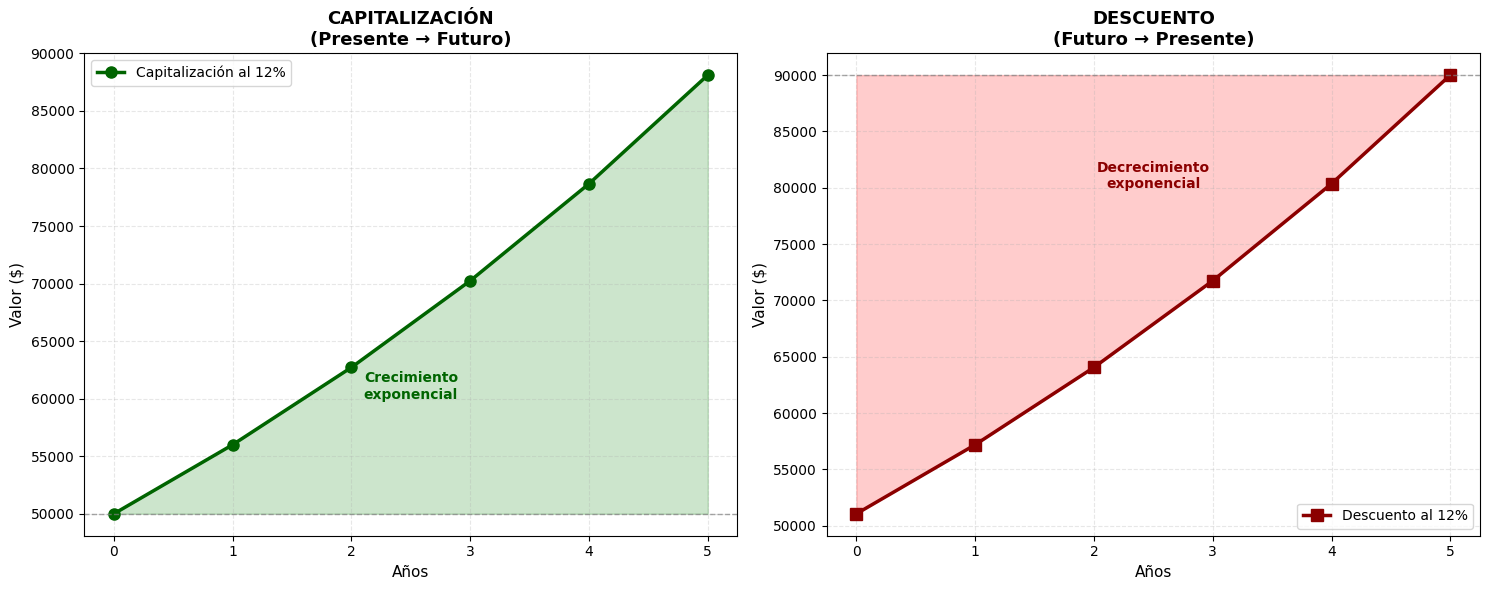


📊 Interpretación de los gráficos:
   • CAPITALIZACIÓN (izq): El dinero crece con el tiempo
   • DESCUENTO (der): El valor presente disminuye cuanto más lejano sea el futuro
   • Ambos procesos son exponenciales (no lineales)


In [15]:
# Visualización: Capitalización vs Descuento

años_grid = np.arange(0, años_horizonte + 1)
valores_capitalizados = capital_inicial * (1 + tasa_anual) ** años_grid
valores_descontados = monto_futuro_prometido / (1 + tasa_anual) ** (años_horizonte - años_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Capitalización
ax1.plot(años_grid, valores_capitalizados, marker='o', linewidth=2.5, 
         color='darkgreen', markersize=8, label=f'Capitalización al {tasa_anual:.0%}')
ax1.axhline(capital_inicial, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.fill_between(años_grid, capital_inicial, valores_capitalizados, alpha=0.2, color='green')
ax1.set_title('CAPITALIZACIÓN\n(Presente → Futuro)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Años', fontsize=11)
ax1.set_ylabel('Valor ($)', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
ax1.text(2.5, capital_inicial + 10000, 'Crecimiento\nexponencial', 
         fontsize=10, ha='center', color='darkgreen', fontweight='bold')

# Gráfico 2: Descuento
ax2.plot(años_grid, valores_descontados, marker='s', linewidth=2.5, 
         color='darkred', markersize=8, label=f'Descuento al {tasa_anual:.0%}')
ax2.axhline(monto_futuro_prometido, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.fill_between(años_grid, valores_descontados, monto_futuro_prometido, alpha=0.2, color='red')
ax2.set_title('DESCUENTO\n(Futuro → Presente)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Años', fontsize=11)
ax2.set_ylabel('Valor ($)', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)
ax2.text(2.5, monto_futuro_prometido - 10000, 'Decrecimiento\nexponencial', 
         fontsize=10, ha='center', color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación de los gráficos:")
print("   • CAPITALIZACIÓN (izq): El dinero crece con el tiempo")
print("   • DESCUENTO (der): El valor presente disminuye cuanto más lejano sea el futuro")
print("   • Ambos procesos son exponenciales (no lineales)")